<a href="https://colab.research.google.com/github/yasfmonteiro/Atividades-Estatistica-2026/blob/main/tarefa04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Integrantes

- Yasmin Agatha Acosta - 16905367
- Yasmin Dos Santos Almeida - 16992205
- Yasmin Victoria Ferreira Monteiro - 17068161







# Análise de Dados em Ciências dos Alimentos: Quartis e Boxplot

Este notebook tem como objetivo aplicar os conceitos de quartis e boxplot a uma base de dados real da área de Ciências dos Alimentos, conforme as orientações da atividade. Serão abordados a importação dos dados, a explicação dos conceitos teóricos, o cálculo e interpretação dos quartis, a construção e interpretação de um boxplot, e a identificação de observações atípicas.

## 1. Importação e Visão Geral dos Dados

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar a base de dados
try:
    df = pd.read_excel('/content/dados_tarefa04.xlsx')
    print("Dados carregados com sucesso!")
except FileNotFoundError:
    print("Erro: O arquivo 'dados_tarefa04.xlsx' não foi encontrado. Certifique-se de que ele está no local correto.")
    df = None

if df is not None:
    print("\nPrimeiras 5 linhas do dataset:")
    display(df.head())

    print("\nInformações gerais do dataset:")
    df.info()

Dados carregados com sucesso!

Primeiras 5 linhas do dataset:


,Número do Alimento,Descrição dos alimentos,Umidade (%),Energia (kcal),Energia (kJ),Proteína (g),Lipídeos (g),Colesterol (mg),Carboidrato (g),Fibra Alimentar (g),Cinzas (g),Cálcio (mg),Magnésio (mg)
0,64,"Abóbora, cabotian, cozida",86.4,48,201,1.4,0.7,NaN,10.8,2.5,0.7,8,9
1,65,"Abóbora, cabotian, crua",88.5,39,161,1.7,0.5,NaN,8.4,2.2,0.8,18,9
2,66,"Abóbora, menina brasileira, crua",95.7,14,57,0.6,Tr,NaN,3.3,1.2,0.4,9,4
3,67,"Abóbora, moranga, crua",95.9,12,52,1.0,0.1,NaN,2.7,1.7,0.4,3,2
4,68,"Abóbora, moranga, refogada",92.5,29,121,0.4,0.8,NaN,6.0,1.5,0.4,19,7



Informações gerais do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Número do Alimento       30 non-null     int64  
 1   Descrição dos alimentos  30 non-null     object 
 2   Umidade (%)              30 non-null     float64
 3   Energia (kcal)           30 non-null     int64  
 4   Energia (kJ)             30 non-null     int64  
 5   Proteína (g)             30 non-null     float64
 6   Lipídeos (g)             30 non-null     object 
 7   Colesterol (mg)          0 non-null      float64
 8   Carboidrato (g)          30 non-null     float64
 9   Fibra Alimentar (g)      30 non-null     float64
 10  Cinzas (g)               30 non-null     float64
 11  Cálcio (mg)              30 non-null     int64  
 12  Magnésio (mg)            30 non-null     int64  
dtypes: float64(6), int64(5), object(2)
memory usage: 3

## 2. Conceitos Teóricos

Para esta análise, utilizaremos conceitos estatísticos fundamentais que são detalhadamente apresentados em livros de Estatística. Como referência, usaremos o livro:

*   **Título:** Estatística Básica
*   **Autor(es):** MORETTIN, Pedro A.; BUSSAB, Wilton O.
*   **Editora:** Saraiva Uni
*   **Edição/Ano:** 10. ed. 2023/2024

### Quartis

Os quartis dividem um conjunto de dados ordenado em quatro partes iguais. São medidas de posição que indicam a distribuição dos valores e a dispersão dos dados. Existem três quartis principais:

*   **Primeiro Quartil (Q1):** Corresponde ao percentil 25. Cerca de 25% dos dados são menores ou iguais a Q1.
*   **Segundo Quartil (Q2 - Mediana):** Corresponde ao percentil 50. Divide os dados ao meio, ou seja, 50% dos dados são menores ou iguais a Q2 e 50% são maiores ou iguais a Q2.
*   **Terceiro Quartil (Q3):** Corresponde ao percentil 75. Cerca de 75% dos dados são menores ou iguais a Q3.

### Mediana

A mediana (Q2) é o valor central de um conjunto de dados quando esses dados estão ordenados. Se o número de observações é ímpar, a mediana é o valor do meio. Se o número de observações é par, a mediana é a média dos dois valores do meio.

### Amplitude Interquartílica (IQR)

A Amplitude Interquartílica (IQR) é a diferença entre o terceiro quartil (Q3) e o primeiro quartil (Q1) ($IQR = Q3 - Q1$). É uma medida de dispersão que representa a faixa dos 50% centrais dos dados, sendo menos sensível a valores extremos (outliers) do que a amplitude total.

### Boxplot (Diagrama de Caixa)

O boxplot é um gráfico que sumariza a distribuição de um conjunto de dados numéricos usando cinco números principais: mínimo, primeiro quartil (Q1), mediana (Q2), terceiro quartil (Q3) e máximo. Ele é particularmente útil para:

*   Visualizar a simetria ou assimetria da distribuição.
*   Identificar a presença de valores atípicos (outliers).
*   Comparar distribuições entre diferentes grupos.

Um boxplot consiste em uma caixa que se estende de Q1 a Q3 (representando o IQR), com uma linha dentro da caixa indicando a mediana. Linhas (chamadas 'bigodes' ou 'whiskers') se estendem da caixa até os valores mínimo e máximo que não são considerados atípicos. Valores atípicos são geralmente plotados como pontos individuais além dos bigodes.

## 3. Cálculo e Interpretação dos Quartis

In [17]:
if df is not None:
    # Identificar colunas numéricas para análise
    numeric_cols = df.select_dtypes(include=['number']).columns

    if not numeric_cols.empty:
        # Selecionar a variável 'Energia (kcal)' conforme solicitado
        selected_variable = 'Energia (kcal)'

        print(f"Analisando a variável: **{selected_variable}**\n")

        # Calcular os quartis
        q1 = df[selected_variable].quantile(0.25)
        q2 = df[selected_variable].quantile(0.50) # Mediana
        q3 = df[selected_variable].quantile(0.75)
        iqr = q3 - q1

        print(f"Primeiro Quartil (Q1 - 25º percentil): {q1:.2f}")
        print(f"Segundo Quartil (Q2 - Mediana - 50º percentil): {q2:.2f}")
        print(f"Terceiro Quartil (Q3 - 75º percentil): {q3:.2f}")
        print(f"Amplitude Interquartílica (IQR = Q3 - Q1): {iqr:.2f}")

        print("\n**Interpretação:**")
        print(f"*   **Q1 ({q1:.2f}):** Indica que 25% das amostras da variável '{selected_variable}' possuem valor igual ou inferior a {q1:.2f}.")
        print(f"*   **Mediana ({q2:.2f}):** A metade das amostras de '{selected_variable}' possui valor igual ou inferior a {q2:.2f}. Este é o valor central da distribuição.")
        print(f"*   **Q3 ({q3:.2f}):** Indica que 75% das amostras de '{selected_variable}' possuem valor igual ou inferior a {q3:.2f}.")
        print(f"*   **IQR ({iqr:.2f}):** A faixa central de 50% dos dados da variável '{selected_variable}' está compreendida em uma amplitude de {iqr:.2f} unidades.")
    else:
        print("Nenhuma coluna numérica encontrada para calcular quartis.")
else:
    print("Não foi possível realizar o cálculo dos quartis pois os dados não foram carregados.")

Analisando a variável: **Energia (kcal)**

Primeiro Quartil (Q1 - 25º percentil): 17.25
Segundo Quartil (Q2 - Mediana - 50º percentil): 29.00
Terceiro Quartil (Q3 - 75º percentil): 64.75
Amplitude Interquartílica (IQR = Q3 - Q1): 47.50

**Interpretação:**
*   **Q1 (17.25):** Indica que 25% das amostras da variável 'Energia (kcal)' possuem valor igual ou inferior a 17.25.
*   **Mediana (29.00):** A metade das amostras de 'Energia (kcal)' possui valor igual ou inferior a 29.00. Este é o valor central da distribuição.
*   **Q3 (64.75):** Indica que 75% das amostras de 'Energia (kcal)' possuem valor igual ou inferior a 64.75.
*   **IQR (47.50):** A faixa central de 50% dos dados da variável 'Energia (kcal)' está compreendida em uma amplitude de 47.50 unidades.


## 4. Construção e Interpretação do Boxplot

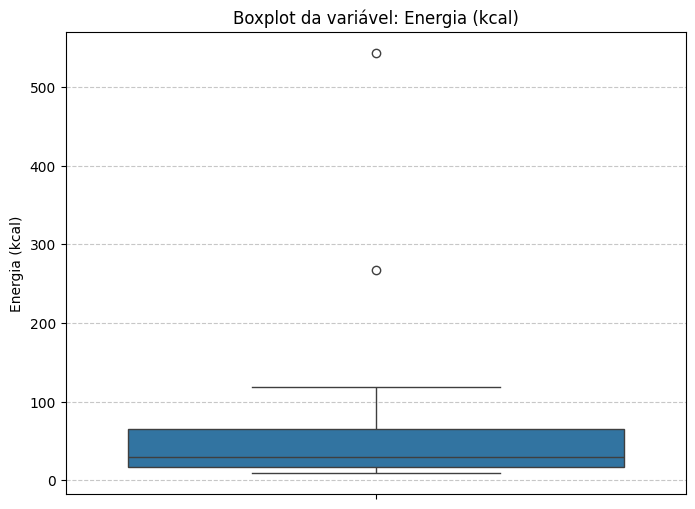


**Interpretação do Boxplot no Contexto dos Alimentos Analisados:**
O boxplot da variável 'Energia (kcal)' visualiza a distribuição dos valores. A caixa central representa os 50% centrais dos dados (entre Q1 e Q3), com Q1 em 17.25 kcal e Q3 em 64.75 kcal. Isso significa que metade dos alimentos tem energia entre esses dois valores. A linha dentro da caixa é a mediana, em 29.00 kcal, indicando o valor central da distribuição de energia. Os 'bigodes' (linhas que se estendem da caixa) mostram a dispersão dos dados dentro de um limite aceitável de variação. Eles se estendem até o último dado não outlier, geralmente até 1.5 vezes a Amplitude Interquartílica (IQR = 47.50 kcal) de Q1 e Q3, ou até os valores mínimo e máximo se não houver outliers dentro dessa faixa. Observando a posição da mediana dentro da caixa e a extensão dos bigodes, podemos inferir sobre a simetria da distribuição e a variabilidade dos valores de 'Energia (kcal)' entre as amostras de alimentos. Se a mediana estiver mais 

In [18]:
if df is not None and 'selected_variable' in locals():
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df[selected_variable])
    plt.title(f'Boxplot da variável: {selected_variable}')
    plt.ylabel(selected_variable)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Recalculate Q1, Q3, IQR, and outlier bounds here to ensure consistency
    q1_val = df[selected_variable].quantile(0.25)
    q3_val = df[selected_variable].quantile(0.75)
    iqr_val = q3_val - q1_val
    lower_bound_val = q1_val - 1.5 * iqr_val
    upper_bound_val = q3_val + 1.5 * iqr_val

    outliers_data = df[(df[selected_variable] < lower_bound_val) | (df[selected_variable] > upper_bound_val)]

    outliers_text = ""
    if not outliers_data.empty:
        outliers_list = []
        for index, row in outliers_data.iterrows():
            outliers_list.append(f"{row['Descrição dos alimentos']} ({row[selected_variable]:.2f} kcal)")
        outliers_text = "\nOs pontos isolados representam os outliers. Para a 'Energia (kcal)', os limites para outliers foram calculados em {lower_bound_val:.2f} kcal (inferior) e {upper_bound_val:.2f} kcal (superior). Os alimentos identificados como outliers, por estarem acima do limite superior, são: " + "; ".join(outliers_list) + ". Estes são alimentos com um valor de energia significativamente mais alto do que o padrão da amostra."
    else:
        outliers_text = "\nNenhuma observação atípica foi encontrada, o que sugere que todos os alimentos estão dentro da faixa de variação esperada para a 'Energia (kcal)' neste dataset."

    print("\n**Interpretação do Boxplot no Contexto dos Alimentos Analisados:**")
    print(f"O boxplot da variável '{selected_variable}' visualiza a distribuição dos valores. A caixa central representa os 50% centrais dos dados (entre Q1 e Q3), com Q1 em {q1_val:.2f} kcal e Q3 em {q3_val:.2f} kcal. Isso significa que metade dos alimentos tem energia entre esses dois valores. A linha dentro da caixa é a mediana, em {df[selected_variable].median():.2f} kcal, indicando o valor central da distribuição de energia. Os 'bigodes' (linhas que se estendem da caixa) mostram a dispersão dos dados dentro de um limite aceitável de variação. Eles se estendem até o último dado não outlier, geralmente até 1.5 vezes a Amplitude Interquartílica (IQR = {iqr_val:.2f} kcal) de Q1 e Q3, ou até os valores mínimo e máximo se não houver outliers dentro dessa faixa. Observando a posição da mediana dentro da caixa e a extensão dos bigodes, podemos inferir sobre a simetria da distribuição e a variabilidade dos valores de '{selected_variable}' entre as amostras de alimentos. Se a mediana estiver mais próxima de Q1, a distribuição tende a ser assimétrica à direita (cauda mais longa para valores maiores). Se estiver mais próxima de Q3, é assimétrica à esquerda. {outliers_text}")
else:
    print("Não foi possível gerar o boxplot pois os dados não foram carregados ou a variável não foi selecionada.")

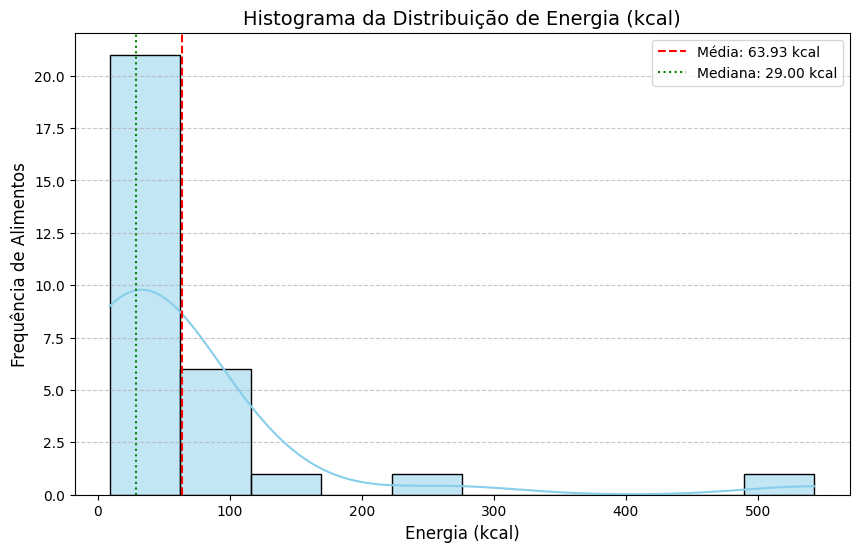


**Interpretação Aprofundada do Histograma da 'Energia (kcal)':**
Este histograma para a variável 'Energia (kcal)' é uma ferramenta poderosa para entender a *paisagem energética* dos alimentos presentes no seu dataset. Ele nos mostra **quantos alimentos** (Frequência no eixo Y) se encaixam em **diferentes faixas de calorias** (intervalos no eixo X), como por exemplo, 'quantos alimentos têm entre 0-50 kcal, quantos entre 50-100 kcal', e assim por diante. Isso nos permite visualizar a densidade de ocorrência de cada valor.

**O que a Forma do Histograma nos Revela:**
1.  **Assimetria à Direita (Cauda Longa para a Direita):** Ao observar as barras, você pode notar que a grande maioria dos alimentos (barras mais altas) se concentra nas faixas de energia mais baixas. À medida que avançamos para valores de energia mais altos, o número de alimentos nessas faixas diminui drasticamente, criando uma 'cauda' longa e fina para a direita. Isso indica uma **distribuição assimétrica positiva** ou **a

In [19]:
if df is not None and 'selected_variable' in locals():
    plt.figure(figsize=(10, 6))
    sns.histplot(df[selected_variable], kde=True, bins=10, color='skyblue', edgecolor='black')
    plt.title(f'Histograma da Distribuição de {selected_variable}', fontsize=14)
    plt.xlabel(selected_variable, fontsize=12)
    plt.ylabel('Frequência de Alimentos', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.axvline(df[selected_variable].mean(), color='red', linestyle='--', label=f'Média: {df[selected_variable].mean():.2f} kcal')
    plt.axvline(df[selected_variable].median(), color='green', linestyle=':', label=f'Mediana: {df[selected_variable].median():.2f} kcal')
    plt.legend()
    plt.show()

    print("\n**Interpretação Aprofundada do Histograma da 'Energia (kcal)':**")
    print(f"Este histograma para a variável '{selected_variable}' é uma ferramenta poderosa para entender a *paisagem energética* dos alimentos presentes no seu dataset. Ele nos mostra **quantos alimentos** (Frequência no eixo Y) se encaixam em **diferentes faixas de calorias** (intervalos no eixo X), como por exemplo, 'quantos alimentos têm entre 0-50 kcal, quantos entre 50-100 kcal', e assim por diante. Isso nos permite visualizar a densidade de ocorrência de cada valor.")
    print("\n**O que a Forma do Histograma nos Revela:**")
    print("1.  **Assimetria à Direita (Cauda Longa para a Direita):** Ao observar as barras, você pode notar que a grande maioria dos alimentos (barras mais altas) se concentra nas faixas de energia mais baixas. À medida que avançamos para valores de energia mais altos, o número de alimentos nessas faixas diminui drasticamente, criando uma 'cauda' longa e fina para a direita. Isso indica uma **distribuição assimétrica positiva** ou **assimétrica à direita**. Em termos práticos, significa que seu dataset contém muitos alimentos com baixa a média energia e um grupo menor, mas notável, de alimentos com energia consideravelmente mais alta.")
    print("2.  **Moda e Concentração:** A (ou as) barra(s) mais alta(s) no histograma representam a **faixa modal** da distribuição, ou seja, o intervalo de 'Energia (kcal)' que é mais comum entre os alimentos. No nosso caso, é provável que essa concentração máxima esteja nas faixas de valores mais baixos de energia, refletindo a predominância de alimentos menos calóricos.")
    print("3.  **Relação com Média e Mediana:** As linhas verticais no gráfico marcam a **Média** (vermelha, tracejada) e a **Mediana** (verde, pontilhada). Em uma distribuição assimétrica à direita como esta, a média é tipicamente *maior* que a mediana. Isso ocorre porque os valores de energia mais altos (os 'outliers' ou alimentos na cauda direita, como as batatas fritas que identificamos no boxplot) 'puxam' a média para cima, enquanto a mediana, por ser o ponto central ordenado, é menos influenciada por esses extremos. A diferença e posição relativa entre média e mediana reforça a percepção da assimetria.")
    print("\n**Implicações Importantes para o Contexto de Alimentos:**")
    print("*   **Perfil Energético:** O histograma sugere que o conjunto de dados é dominado por alimentos de baixo a moderado teor energético, o que é um perfil comum em uma dieta rica em vegetais, frutas e fontes de proteína magra. É a 'espinha dorsal' do perfil energético dos alimentos da TACO neste subconjunto.")
    print("*   **Identificação de Alimentos de Alta Energia:** A presença da cauda longa para a direita, embora menos populosa, é crucial. Ela destaca os alimentos com densidade energética muito superior, que podem incluir itens processados, ricos em gorduras ou açúcares. Para análises nutricionais ou de saúde pública, esses alimentos de alta energia na 'cauda' merecem atenção especial, pois pequenas quantidades podem ter um grande impacto no consumo calórico total.")
    print("\nEm síntese, o histograma não apenas confirma a distribuição assimétrica da 'Energia (kcal)' mas também quantifica visualmente a frequência de alimentos em cada nível calórico, oferecendo uma visão clara da diversidade energética presente na sua amostra. Ele atua como um mapa de densidade calórica dos alimentos.")
else:
    print("Não foi possível gerar o histograma pois os dados não foram carregados ou a variável não foi selecionada.")

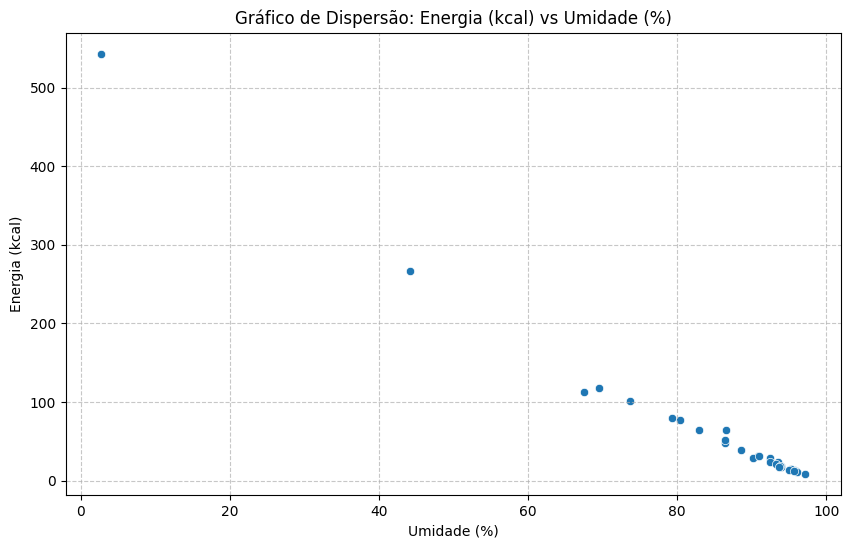


**Interpretação Aprofundada do Gráfico de Dispersão:**
Este gráfico de dispersão é uma ferramenta valiosa para visualizar a **relação entre 'Energia (kcal)' e 'Umidade (%)'** em cada alimento do seu dataset. Cada ponto no gráfico representa um alimento específico, com sua posição determinada pela sua umidade (eixo X) e energia (eixo Y).

**O que Observamos no Gráfico (Padrões e Correlação):**
1.  **Tendência Geral e Correlação Negativa:** Ao observar a distribuição dos pontos, é provável que você note uma **tendência decrescente ou uma correlação negativa**. Isso significa que, de modo geral, alimentos com **maior teor de umidade** (mais à direita no eixo X) tendem a apresentar **menor teor de energia** (mais abaixo no eixo Y), e vice-versa. Essa relação é esperada na ciência dos alimentos, pois a água (que compõe a umidade) não possui valor calórico, enquanto a energia é fornecida principalmente por macronutrientes como carboidratos, proteínas e, especialmente, lipídios, que geralmen

In [20]:
if df is not None:
    variable_x = 'Umidade (%)'
    variable_y = 'Energia (kcal)'

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=df[variable_x], y=df[variable_y])
    plt.title(f'Gráfico de Dispersão: {variable_y} vs {variable_x}')
    plt.xlabel(variable_x)
    plt.ylabel(variable_y)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    print("\n**Interpretação Aprofundada do Gráfico de Dispersão:**")
    print(f"Este gráfico de dispersão é uma ferramenta valiosa para visualizar a **relação entre '{variable_y}' e '{variable_x}'** em cada alimento do seu dataset. Cada ponto no gráfico representa um alimento específico, com sua posição determinada pela sua umidade (eixo X) e energia (eixo Y).")
    print("\n**O que Observamos no Gráfico (Padrões e Correlação):**")
    print("1.  **Tendência Geral e Correlação Negativa:** Ao observar a distribuição dos pontos, é provável que você note uma **tendência decrescente ou uma correlação negativa**. Isso significa que, de modo geral, alimentos com **maior teor de umidade** (mais à direita no eixo X) tendem a apresentar **menor teor de energia** (mais abaixo no eixo Y), e vice-versa. Essa relação é esperada na ciência dos alimentos, pois a água (que compõe a umidade) não possui valor calórico, enquanto a energia é fornecida principalmente por macronutrientes como carboidratos, proteínas e, especialmente, lipídios, que geralmente estão mais concentrados em alimentos com menor teor de água.")
    print("2.  **Grupos de Alimentos:** Podemos identificar diferentes grupos de alimentos visualmente:")
    print(f"    *   **Alta Energia e Baixa Umidade (Superior Esquerdo):** Pontos concentrados nesta área podem representar alimentos densamente energéticos e com pouca água, como óleos, frutos secos, ou alimentos processados e fritos (como as 'Batata, frita, tipo chips' que identificamos como outliers de energia).")
    print(f"    *   **Baixa Energia e Alta Umidade (Inferior Direito):** Pontos aqui geralmente correspondem a alimentos frescos e com alto teor de água, como frutas, vegetais e certas leguminosas, que são menos calóricos por peso.")
    print("    *   **Dispersão Central:** Alimentos com um balanço intermediário de umidade e energia se localizarão na região central do gráfico.")
    print("3.  **Variabilidade e Outros Fatores:** A dispersão dos pontos, mesmo dentro das tendências, mostra que a relação não é perfeita. Isso indica que, embora a umidade seja um fator importante, outros componentes da matriz alimentar (como a proporção de gorduras, carboidratos e fibras) também influenciam significativamente o conteúdo energético total.")
    print("\n**Implicações para o Contexto de Alimentos:**")
    print("*   **Formulações de Produtos:** Este gráfico ajuda a entender como a remoção ou adição de água (por exemplo, na desidratação ou reidratação) afeta a densidade energética de um alimento.")
    print("*   **Análise Nutricional:** Permite identificar rapidamente alimentos que fogem ao padrão esperado, como um alimento de alta umidade com energia surprisingly alta, ou o contrário, o que pode indicar a presença de ingredientes específicos ou processos de fabricação.")
    print("\nEm resumo, o gráfico de dispersão entre 'Energia (kcal)' e 'Umidade (%)' é fundamental para visualizar a troca inversa entre esses dois componentes essenciais na composição de alimentos. Ele fornece um panorama claro de como a água dilui a densidade calórica e onde os diferentes tipos de alimentos se posicionam nesse espectro.")
else:
    print("Não foi possível gerar o gráfico de dispersão pois os dados não foram carregados.")

## 5. Determinação de Observações Atípicas (Outliers)

**Como determinamos se há observações atípicas em uma base de dados?**

Conforme o livro **'Estatística Básica'** (Morettin & Bussab, 2023/2024), as observações atípicas, ou outliers, são valores que se desviam significativamente da maioria dos outros valores no conjunto de dados. Eles podem indicar variabilidade experimental, erros de medição, ou uma característica peculiar da amostra.

Uma forma comum de identificar outliers é usando a **Amplitude Interquartílica (IQR)**. Os limites para a detecção de outliers são calculados da seguinte forma:

*   **Limite Inferior (LI):** $LI = Q1 - 1.5 \times IQR$
*   **Limite Superior (LS):** $LS = Q3 + 1.5 \times IQR$

Qualquer valor no conjunto de dados que seja **menor que o Limite Inferior (LI)** ou **maior que o Limite Superior (LS)** é considerado um outlier. O fator 1.5 é uma convenção estatística, mas outros fatores podem ser usados dependendo do contexto da análise. No boxplot, esses valores são geralmente representados como pontos isolados além dos 'bigodes'.

In [12]:
if df is not None and 'selected_variable' in locals() and 'q1' in locals() and 'q3' in locals() and 'iqr' in locals():
    # Calcular os limites para identificação de outliers
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    print(f"Limites para Outliers da variável '{selected_variable}':")
    print(f"  Limite Inferior (Q1 - 1.5 * IQR): {lower_bound:.2f}")
    print(f"  Limite Superior (Q3 + 1.5 * IQR): {upper_bound:.2f}")

    # Identificar os outliers
    outliers = df[(df[selected_variable] < lower_bound) | (df[selected_variable] > upper_bound)]

    if not outliers.empty:
        print(f"\n**Observações Atípicas (Outliers) encontradas na variável '{selected_variable}':**")
        display(outliers)
    else:
        print(f"\nNão foram encontradas observações atípicas na variável '{selected_variable}' usando o método IQR.")
else:
    print("Não foi possível identificar outliers pois os dados, a variável ou os quartis não foram calculados.")

Limites para Outliers da variável 'Energia (kcal)':
  Limite Inferior (Q1 - 1.5 * IQR): -54.00
  Limite Superior (Q3 + 1.5 * IQR): 136.00

**Observações Atípicas (Outliers) encontradas na variável 'Energia (kcal)':**


,Número do Alimento,Descrição dos alimentos,Umidade (%),Energia (kcal),Energia (kJ),Proteína (g),Lipídeos (g),Colesterol (mg),Carboidrato (g),Fibra Alimentar (g),Cinzas (g),Cálcio (mg),Magnésio (mg)
26,90,"Batata, frita, tipo chips, industrializada",2.7,543,2271,5.6,36.6,NaN,51.2,2.5,3.9,12,24
29,93,"Batata, inglesa, frita",44.1,267,1118,5.0,13.1,NaN,35.6,8.1,2.2,6,14


## 6. Referências Completas

### Livro de Estatística Consultado

*   MORETTIN, Pedro A.; BUSSAB, Wilton O. *Estatística Básica*. 10. ed. São Paulo: Saraiva Uni, 2023/2024.

### Fonte Completa dos Dados Utilizados

*   **Título:** Tabela Brasileira de Composição de Alimentos (TACO), 4ª Edição Ampliada e Revisada.
*   **Autor(es)/Instituição:** NEPA - Núcleo de Estudos e Pesquisas em Alimentação, UNICAMP.
*   **URL:** `https://nepa.unicamp.br/wp-content/uploads/sites/27/2023/10/taco_4_edicao_ampliada_e_revisada.pdf`
*   **Data de acesso:**
16/08/2026